<a href="https://colab.research.google.com/github/stephentangzizhong/Neuroinformatics-Workshop-Code/blob/main/9_In_course_Assessment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**NEUR0019: In-course Assessment (2025/26)**

Please use File -> Save a Copy in Drive to save a copy of this notebook in your own Google drive

Then answer all the questions below by filling in the text and code cells as appropriate

When you are done, use File -> Download .ipynb and submit the Python notebook file (*.ipynb) via the Moodle page

**Please make sure** to include your candidate number here: **XYKX9**

**Please also remember** that the use of  AI to complete this assignment is strictly prohibited! Before you start, go to Tools -> Settings -> AI assistance, and click "Hide generative AI features". Please also avoid working together on this assignment.

First, we will load some place cell data from the Buzsaki lab, to run some analyses on

In [ ]:
# Import the class data and requisite toolboxes
!git clone https://github.com/kdharris101/NeuralCodingClass.git
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import NeuralCodingClass.neurocode as nc

Cloning into 'NeuralCodingClass'...
remote: Enumerating objects: 299, done.
remote: Counting objects: 100% (22/22), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 299 (delta 1), reused 18 (delta 1), pack-reused 277 (from 1)
Receiving objects: 100% (299/299), 392.13 MiB | 17.95 MiB/s, done.
Resolving deltas: 100% (101/101), done.
Updating files: 100% (269/269), done.


In [ ]:
# Import some sample place cell data from the Buzsaki lab
FileDir = r'NeuralCodingClass/data/buzsaki'
Experiment = 'ec014.277'
spikes = nc.load_object(os.path.join(FileDir, Experiment, 'spikes'))
tracking = nc.load_object(os.path.join(FileDir, Experiment, 'tracking'))

In [ ]:
# These two data objects - 'spikes' and 'tracking' - are each a "Bunch", a simple
# structure that contains many arrays of data, all with the same number entries.
# Specifically, 'spikes' has one entry per spike, and 'tracking' has one entry per
# time bin

# We can inspect the contents of each as follows:
for k in spikes.keys():
  print(f'spikes.{k:<20}: size {spikes[k].shape}\t dtype {spikes[k].dtype}')

for k in tracking.keys():
  print(f'tracking.{k:<20}: size {tracking[k].shape}\t dtype {tracking[k].dtype}')

# These entries correspond to:

# spikes.times: the time (in seconds) of each detected spike
# spikes.clusters: the putative cell ID that fired each spike
# spikes.pos: the position of the animal at the time of each spike (x,y coordinates for two LEDs placed on the rat's head)

# tracking.times: the time points (in seconds) at which tracking (e.g. position) data was sampled
# tracking.spike_counts: time points x clusters array with spike counts for each putative cell in each timepoint
# tracking.pos: the position of the animal at each tracking time point (x,y coordinates for two LEDs placed on the rat's head)
# tracking.speed: the running speed of the animal at each tracking time point ()
# tracking.good: Boolean array, which is True if LEDs could be detected at this timepoint

spikes.clusters            : size (599979,)	 dtype int64
spikes.pos                 : size (599979, 4)	 dtype float64
spikes.times               : size (599979,)	 dtype float64
tracking.spike_counts        : size (215399, 77)	 dtype uint8
tracking.pos                 : size (215399, 4)	 dtype float64
tracking.speed               : size (215399,)	 dtype float64
tracking.good                : size (215399,)	 dtype bool
tracking.times               : size (215399,)	 dtype float64


Next, we will define some useful functions - for generating firing rate maps from these spike and tracking data arrays, and for computing temporal auto-correlations of the corresponding spike trains

In [ ]:
def compute_placefield(tracking_pos, tracking_spike_counts, smoothing_width=4,
                       window_size=25, env_size=None, eps=.01, speed_thresh=0, dt=512/20000):
    """
    Generates spatial firing rate maps for multiple cells simultaneously

    inputs:
    -------
    tracking_pos: T by 2 array of x-y positions

    tracking_spike_counts: T by N_cells array of spike counts in each tracking time point for each cell

    smoothing_width: width of Gaussian to smooth occupancy and firing rate maps

    window_size: width of square convolution window that contains the Gaussian
      (larger=>code runs slower but better results)

    env_size: [Nx Ny] size of integer grid to compute firing rate map on.  Default: max + window_size

    eps: regularisation (areas visited less than eps s will be given ~mean rate)

    speed_thresh: only count timesteps for which the Eucildean speed (per tracking sample) is >= this (so 0 means use everything)

    dt: time bin size (default: Buzsaki lab standard 0.0256 s)

    returns:

    place_map: Nx by Ny by Ncells array of smoothed firing rates (spks/s)

    occ_map: Nx by Ny array of smoothed occupancy times (s)

    """

    # Assign firing rate map size by default, if none is specified
    if env_size is None:
        env_size = np.nanmax(tracking_pos,axis=0) + window_size

    # Generate smoothing kernel
    gauss0 = signal.windows.gaussian(window_size, smoothing_width)
    gauss = gauss0[:,None]* gauss0[None,:]

    # Compute running speed for each time point
    tracking_speed = np.sqrt((np.diff(tracking_pos, axis=0, prepend = np.nan)**2).sum(axis=1))

    # Identify the time bins to include (above running speed threshold)
    tracking_use = (tracking_speed>=speed_thresh)

    # Generate occupancy map (time spent in each spatial bin)
    occupancy_map = np.histogramdd(tracking_pos[tracking_use,:],
                                   [np.arange(env_size[0]), np.arange(env_size[1])])[0]*dt

    # Generate spike count map (spikes fired by each cell in each spatial bin)
    count_map = np.zeros((*occupancy_map.shape, tracking_spike_counts.shape[1]))
    for c in range(tracking_spike_counts.shape[1]):
        count_map[:,:,c] = np.histogramdd(tracking_pos[tracking_use,:],
                                   bins=[np.arange(env_size[0]), np.arange(env_size[1])],
                                   weights=tracking_spike_counts[tracking_use,c])[0]

    # Smooth both occupancy and spike count maps
    occ_map_sm = signal.convolve2d(occupancy_map, gauss, 'same')
    count_map_sm = signal.convolve(count_map, gauss[:,:,None], 'same')

    # Compute mean firing rate of each cell in each spatial bin
    mean_rate = count_map.sum(axis=(0,1), keepdims=True) / occupancy_map.sum()

    # Compute output firing rate map (with regularisation)
    place_map = (count_map_sm + eps*mean_rate)/ (occ_map_sm + eps)[:,:,None]

    # Return outputs
    return place_map, occ_map_sm

In [ ]:
def compute_bits(tracking,eps=.01,kFolds=5):

    """
    Computes spatial information in bits per second for multiple cells simultaneously

    inputs:
    -------
    tracking: tracking data structure

    eps: regularisation (areas visited less than eps s will be given ~mean rate)

    kFolds: number of folds for cross-validation

    """

    # Extract some parameters from the input
    Nt = len(tracking)                                # total number of tracking timepoints
    Nt_good = np.sum(tracking.good)                   # number of timepoints with tracking data
    dt = 512.0/20000                                  # time bin size (default: Buzsaki lab standard 0.0256 s)
    mean_rate_all = tracking.spike_counts.mean(0)/dt  # compute the mean firing rate of all cells
    Nc = tracking.spike_counts.shape[1]               # extract the total number of cells
    pos_cols = np.s_[:2]                              # use the first two columns of tracking data (to look at the front LED only)

    # Assign some memory for the output
    score_L = np.zeros((Nc, kFolds))                  # L score for each fold based on firing rate map
    score_L0 = np.zeros((Nc, kFolds))                 # L score for each fold based on training-set mean rate

    # Loop through folds
    for k in range(kFolds):

      # Separate time points into train and test sets
      test = np.where((np.arange(Nt)>=k*Nt/kFolds) & (np.arange(Nt)<(k+1)*Nt/kFolds) & (tracking.good))[0]
      train = np.setdiff1d(np.where(tracking.good)[0], test)

      # Generate firing rate maps for all cells from the training set
      place_map_train, occ_map_train = compute_placefield(tracking.pos[train,pos_cols],
                                  tracking.spike_counts[train,:],eps=eps)

      # Compute mean rate of all cells from training set
      mean_rate_train = tracking.spike_counts[train,:].mean(0,keepdims=True)/dt

      # Convert positions in the test set into integer arrays so we can look up rates
      test_pos_x = np.floor(tracking.pos[test][:,pos_cols][:,0]).astype(int)
      test_pos_y = np.floor(tracking.pos[test][:,pos_cols][:,1]).astype(int)

      # Look up rates from the firing rate maps at all test set timepoints
      pred_rate = place_map_train[test_pos_x[:,None], test_pos_y[:,None], np.arange(Nc)[None,:]]

      # Extract the actual spike counts at all test set timepoints
      spike_counts_test = tracking.spike_counts[test,:]

      # Compute spatial information based on the firing rate map and mean rates
      with np.errstate(divide = 'ignore', invalid='ignore'):
        score_L[:,k] = np.sum(np.log(pred_rate)*spike_counts_test - pred_rate*dt,0)
        score_L0[:,k] = np.sum(np.log(mean_rate_train)*spike_counts_test - mean_rate_train*dt,0)

    # Finally, average L and L0 over folds, normalize to compute bits/s and return the outputs
    bits_per_second = np.sum(score_L-score_L0,1)/dt/Nt_good/np.log(2)
    return bits_per_second

In [ ]:
def plot_tac(spike_train,bin_size=512/20000,range=0.5):

    """
    Generates and plots the temporal auto-correlation of a given spike train

    inputs:
    -------
    spike_train: binned spike counts for a given cell

    bin_size: time bin size of the spike count vector (s)

    range = window size for the temporal auto-correlation (s)

    """

    # Compute the temporal auto-correlation
    autocorr = np.correlate(spike_train,spike_train,mode='full')              # Generate the temporal auto-correlation
    strt_ind = np.size(autocorr)/2 - (range/bin_size)                         # Find the start index of the window of interest
    end_ind  = np.size(autocorr)/2 + (range/bin_size)                         # Find the end index of the window of interest
    autocorr = autocorr[int(strt_ind):int(end_ind+1)]                         # Discard any values beyond the window of time lags we are interested in
    autocorr[int(len(autocorr)/2)] = 0                                        # Eliminate zero-lag autocorrelation
    autocorr = autocorr/(bin_size*(spike_train.sum()))                        # Normalize the auto-correlation to convert to firing rate (Hz)

    # Generate a figure to show the temporal auto-correlation
    plt.figure()                                                              # Generate a new figure
    plt.plot(np.arange(-range-bin_size/2,range+bin_size/2,bin_size),autocorr) # Plot the temporal auto-correlation
    plt.xlabel('Time (s)',fontsize=24)                                        # Label the x-axis
    plt.ylabel('Firing rate (Hz)',fontsize=24)                                # Label the y-axis
    plt.show()                                                                # Show the figure

**Q1:** The code below identifies entries in the tracking data from the first fifteen minutes (i.e. 900 s) of the recording, and then plots the binned spike counts for the second recorded cell (i.e. with index 1) during that time window.

Add an additional line of code that also plots the temporal auto-correlation of that spike train (i.e. from the cell with index 1, for the first 900 s of the recording)

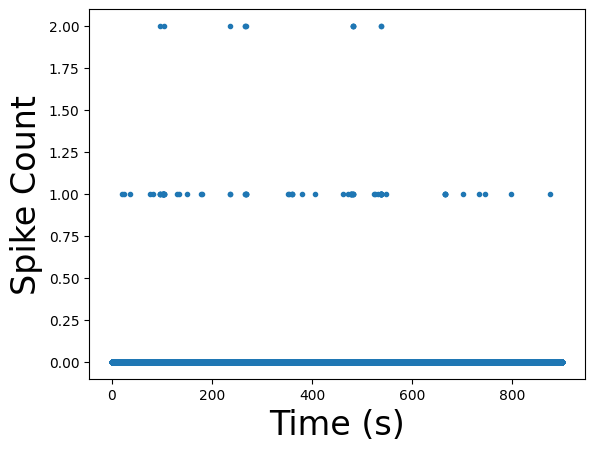

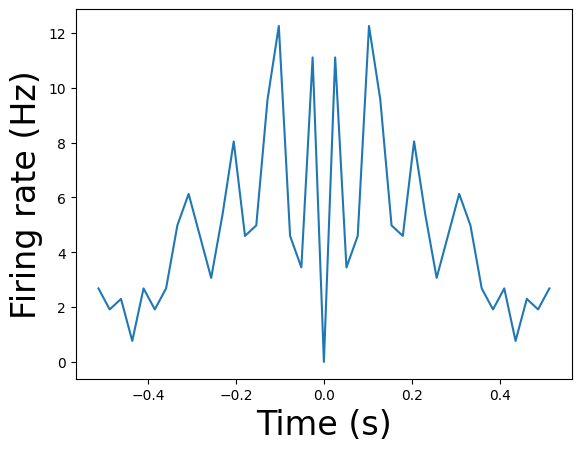

In [ ]:
# Find entries in the tracking arrays that fall within the first 900 s of the recording
include = (tracking.times<=900)

# Plot binned spike counts for the  cell with index 1 within this time window
plt.figure()
plt.plot(tracking.times[include], tracking.spike_counts[include,1], '.')
plt.xlabel('Time (s)',fontsize=24)
plt.ylabel('Spike Count',fontsize=24)
plt.show()

# Write your answer here
plot_tac(tracking.spike_counts[include,1])

**Q2:** The temporal auto-correlation shows the mean firing rate of that cell as a function of the time lag since it last fired a spike. The temporal auto-correlation above shows a strong peak at a lag of ~125ms, implying that this spike train is rhythmically modulated. What is the approximate frequency of that modulation?

8 Hz

**Q3:** Is this spike train well approximated by a Poisson process? Explain your reasoning. More generally, what properties of all recorded spike trains make them different from a Poisson process?

No. The Poisson process estimates the probability of getting n spikes given the mean number of spikes. It cares about the number of spikes within a timewindow, and assumes each spike to occur independently from one another. However, here, these recorded spike trains encode information temporally. Spikes have temporal relationships. Therefore, the timepoints of spikes, but not simply their count, matter. The temporal information carried by spike trains approximated by a Poisson process cannot be reflected in the temporal autocorrelogram.

**Q4:** The code below generates firing rate maps for all the cells in this data set,and then plots firing rate maps for three example cells. Which of these cells do you think carries the most information about the location of the animal, and why?

I think Cell 6 carries the most information.

Example 1 (Cell 4): Although the peak firing rate is the highest, the firing rate map looks dispersed, which means the neuron might not be coding for the spatial information, but involved in other activities.

Example 2 (Cell 6): The peak firing rate is high and the firing rate map looks concentrated to mostly one spot, stongly suggesting that the neuron carries spatial information for that location.

Example 3 (Cell 63): The map looks clean and concentrated to one spot, but the peak firing rate is very low. The neuron is not firing reliably at that location.

In [ ]:
pos_cols = np.s_[:2] # Use the first two columns of tracking data (to look at the front LED only)

rate_map,occ_map = compute_placefield(tracking.pos[:,pos_cols], tracking.spike_counts)

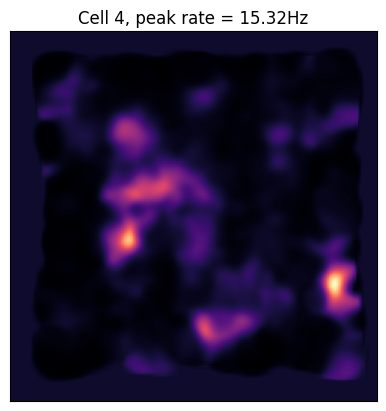

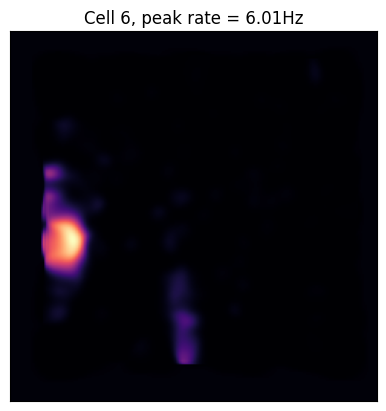

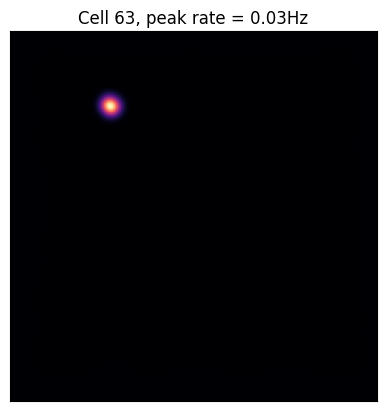

In [ ]:
cells_to_plot = [4,6,63]

for c in cells_to_plot:
  plt.figure()
  plt.imshow(rate_map[:,:,c].transpose(1,0),cmap='magma')
  max_rate = rate_map[:,:,c].max()
  plt.title('Cell ' + str(c) + ', peak rate = ' + str(np.round(max_rate,2)) + 'Hz')
  plt.xticks([]), plt.yticks([])
  plt.xlim(50,290)
  plt.show()

**Q5:** The code below estimates the spatial information provided by all recorded cells and then displays those values for each of the three cells above. Do these results match your intuition?

Yes, as expected, cell 6 carries the most spatial information.  However, it's surprising that cell 63, with such an almost negligible peak rate (~500 times less than cell 4), carries 2.5 times more information than cell 4. This indicates that precise timing conveys more information than firing rate.

In [ ]:
spatial_info = compute_bits(tracking)

for c in cells_to_plot:
  print('Spatial information for cell ' + str(c) + ': ' + str(np.round(spatial_info[c-1],2)) + ' bits / s')

Spatial information for cell 4: 0.05 bits / s
Spatial information for cell 6: 0.6 bits / s
Spatial information for cell 63: 0.13 bits / s


**Q6:** Adapt the code above to compute spatial information for these example cells using the default value of eps = .01 and also for eps = 0.1, eps = 0.5, eps = 2, eps = 4, eps = 6, and eps = 8

Why do different values of epsilon result in different estimates of the spatial information provided by each cell?

Why do different cells show peak spatial information for different values of eps?

[Question 6 Answer]

Adding epsilon 'dilutes' the false high rates calculated due to very short occupancies, therefore reducing the 'noise'.

For Cell 4, the firing rate map is dispersed, not very concentrated to specifc locations. Increasing the value of eps reduces noise and increases the contrast. The estimate of spatial information increases as eps increases, and reaches a plateau after eps=2.

For Cell 6, the estimate of information peaks at eps=0.5 and then gradually decreases as eps increases. Initially, the increase in epsilon may reduce noise and make the most responsive location more visible. But as eps gets larger, the encoded information is averaged out.

For Cell 63, the estimate of information peaks at eps=2-4 and graudually decreases afterwards. Since the firings are very rare, we need a longer eps to reduce the noise.

In conclusion, the cells show peak spatial information for different values of eps probably due to different distributions of noise.

In [ ]:
for a in [0.01, 0.1, 0.5, 2, 4, 6, 8]:

  spatial_info = compute_bits(tracking, eps=a)

  for c in cells_to_plot:
    print('When eps=' + str(a) + ', Spatial information for cell ' + str(c) + ': ' + str(np.round(spatial_info[c-1],2)) + ' bits / s')

When eps=0.01, Spatial information for cell 4: 0.05 bits / s
When eps=0.01, Spatial information for cell 6: 0.6 bits / s
When eps=0.01, Spatial information for cell 63: 0.13 bits / s
When eps=0.1, Spatial information for cell 4: 0.07 bits / s
When eps=0.1, Spatial information for cell 6: 0.63 bits / s
When eps=0.1, Spatial information for cell 63: 0.15 bits / s
When eps=0.5, Spatial information for cell 4: 0.07 bits / s
When eps=0.5, Spatial information for cell 6: 0.64 bits / s
When eps=0.5, Spatial information for cell 63: 0.17 bits / s
When eps=2, Spatial information for cell 4: 0.08 bits / s
When eps=2, Spatial information for cell 6: 0.63 bits / s
When eps=2, Spatial information for cell 63: 0.19 bits / s
When eps=4, Spatial information for cell 4: 0.08 bits / s
When eps=4, Spatial information for cell 6: 0.61 bits / s
When eps=4, Spatial information for cell 63: 0.19 bits / s
When eps=6, Spatial information for cell 4: 0.08 bits / s
When eps=6, Spatial information for cell 6: 0.5